In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
from DataLoader import MyDataloader
from Engine import Engine
import pandas as pd
import matplotlib.pyplot as plt
import torch
import Architecture
import Information as info

In [5]:
data_path = Path(r"/mnt/Data1/Python_Projects/Kaggle/data/titanic/train.csv")
# data_path_heart = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
train_percent = 0.7
val_percent = 0.15
test_percent = 0.15
batch_size = 312
seed = 42
dataloader = MyDataloader(file_path=data_path,
                          train_percent=train_percent, 
                          val_percent=val_percent, 
                          test_percent=test_percent, 
                          batch_size=batch_size, 
                          random_seed=seed)
train, val, test = dataloader.fit()

try:
    print(len(train), len(val), len(test))
except:
    print(len(train), len(val))

2 1 1


In [7]:
a = dataloader.data

In [9]:
b = dataloader.raw_data
b

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [8]:
features_n = len(info.features_dataloader)
target_n = len(info.target_dataloader)
hidden_n = 64
torch.manual_seed(42)
model = Architecture.NN(features_n=features_n, output_n=target_n, hidden_n=hidden_n)

EPOCHS = 300
loss_fn = torch.nn.CrossEntropyLoss()
learning_rate = 0.001

optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)

engine = Engine(model=model, 
                train_dataloader=train,
                val_dataloader=val,
                test_dataloader=test,
                random_seed=42)
model0_results = engine.train(loss_fn=loss_fn,
                              optimizer=optimizer,
                              epochs_num=EPOCHS,
                              resolution=10)


  0%|          | 0/300 [00:00<?, ?it/s]

Epoch 10 | train: Loss 0.668905 Accuracy 0.6292 | validation: Loss 0.679718 Accuracy 0.5224
Epoch 20 | train: Loss 0.633099 Accuracy 0.6774 | validation: Loss 0.649243 Accuracy 0.5896
Epoch 30 | train: Loss 0.576939 Accuracy 0.7592 | validation: Loss 0.592327 Accuracy 0.7015
Epoch 40 | train: Loss 0.527042 Accuracy 0.8186 | validation: Loss 0.534216 Accuracy 0.8060
Epoch 50 | train: Loss 0.504546 Accuracy 0.8186 | validation: Loss 0.511752 Accuracy 0.8060
Epoch 60 | train: Loss 0.496243 Accuracy 0.8186 | validation: Loss 0.503334 Accuracy 0.7985
Epoch 70 | train: Loss 0.492583 Accuracy 0.8186 | validation: Loss 0.500123 Accuracy 0.7985
Epoch 80 | train: Loss 0.490626 Accuracy 0.8186 | validation: Loss 0.499515 Accuracy 0.7910
Epoch 90 | train: Loss 0.489432 Accuracy 0.8202 | validation: Loss 0.499429 Accuracy 0.7910
Epoch 100 | train: Loss 0.488589 Accuracy 0.8202 | validation: Loss 0.499458 Accuracy 0.7910
Epoch 110 | train: Loss 0.487931 Accuracy 0.8186 | validation: Loss 0.499507 Ac

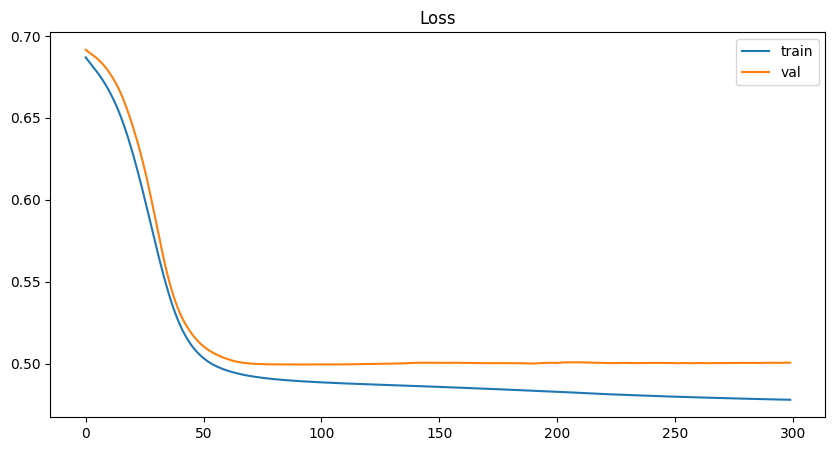

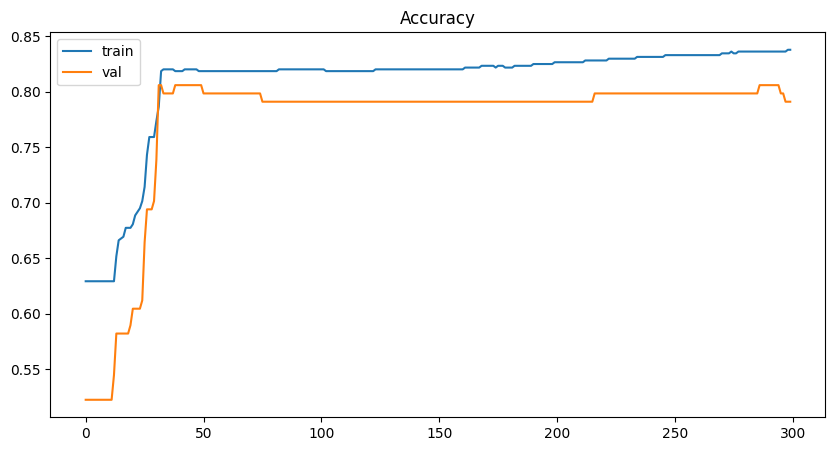

In [9]:
engine.plot_loss()
engine.plot_acc()

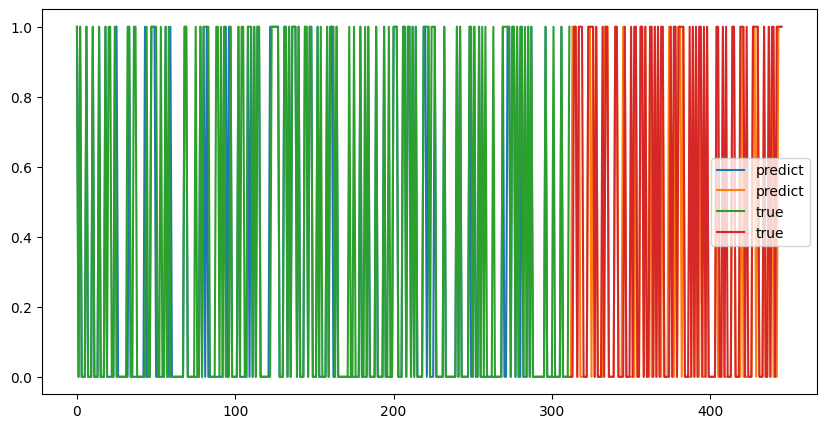

In [33]:
engine.plot_predict_real()

In [10]:
test_result = engine.test(loss_fn=loss_fn)

[!!!IMPORTANT NOTE!!!]
The test_function provided here is intended solely for the final model analysis and reporting purposes.
Please refrain from using it as a general-purpose function in your own projects. Always refer to
the appropriate train and validation data for developing and fine-tuning your own models.
Loss : 0.5133166313171387 and Accuracy : 0.7761194029850746


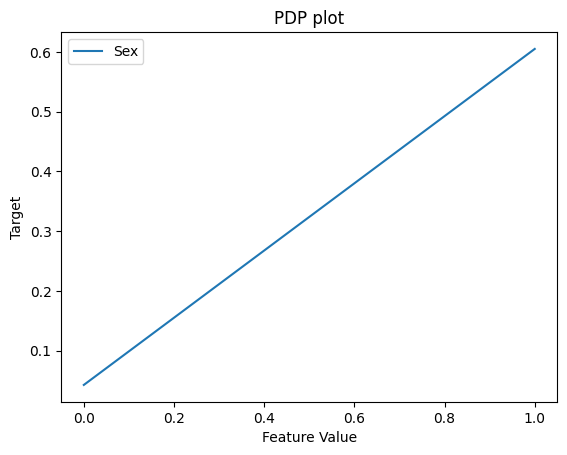

In [16]:
features1 = {"Pclass":[1, 2, 3]}
features2 = {"Age": sorted(list(dataloader.data["Age"].unique()))}
features3 = {"Sex": [0, 1]}
features4 = {"SibSp":[0, 1, 2, 3, 4, 5, 6, 7, 8]}
features5 = {"Fare": sorted(list(dataloader.data["Fare"].unique()))}
features6 = {"Parch": [0, 1, 2, 3, 4, 5, 6]}

pdp_dataloader = dataloader.partial_dependence_plot_data(features=features3)
engine.partial_dependence_plot(pdp_data=pdp_dataloader)

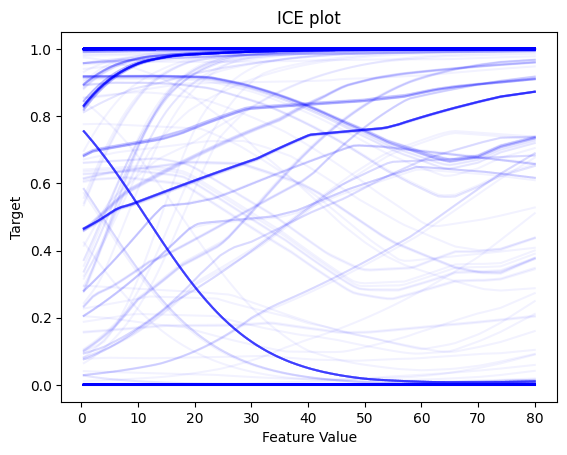

In [23]:
ice_dataloader = dataloader.individual_conditional_expectation_data(features=features2)
engine.individual_conditional_expectation(ice_data=dataloader.ice_data)

[INFO] Empty Interval 0.3333333333333333 to 0.6666666666666666


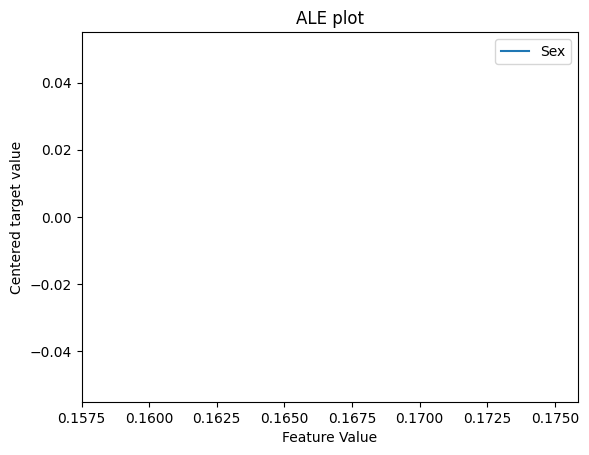

In [15]:
features = ["Pclass", "Age", "Sex", "SibSp", "Fare"]
ale_dataloader = dataloader.accumulated_local_effects_data(feature=features[2], n=3)
engine.accumulated_local_effects_plot(ale_dataloader)

In [64]:
info.features_dataloader

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_0',
       'Embarked_1', 'Embarked_2'],
      dtype='object')

{'Pclass': -0.04418332442167816,
 'Sex': 0.29784667252108354,
 'Age': 0.011232724844059572,
 'SibSp': -0.0018428833461073824,
 'Parch': -0.018398942003994834,
 'Fare': -0.010581575806062338,
 'Embarked_0': -0.029500098272493114,
 'Embarked_1': -0.07449695505305853,
 'Embarked_2': 0.01353540573844425}

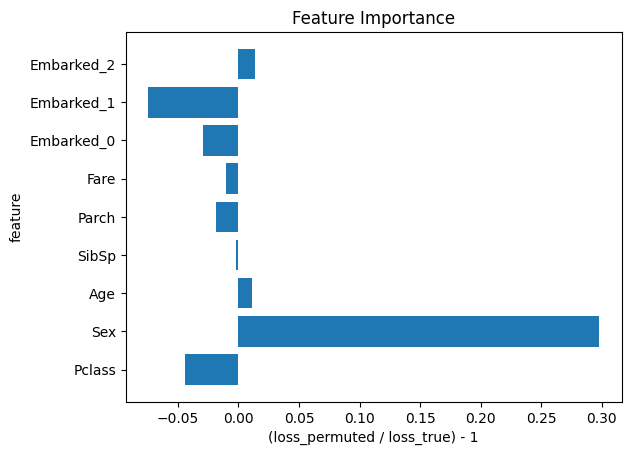

In [109]:
feature_importance_dataloader = dataloader.feature_importance_data(seed=42, data_choice="test")
feature_loss = engine.feature_importance_plot(feature_importance_dataloader, loss_fn=loss_fn)
feature_loss